In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [42]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2,stratify=y)

In [44]:
pd.DataFrame(data=y_train).value_counts()

0    206
1    114
dtype: int64

In [45]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [46]:
from sklearn.neighbors import KNeighborsClassifier
clsf = KNeighborsClassifier(n_neighbors=10,metric='euclidean',p=2)
clsf.fit(X_train_sc,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=10)

In [47]:
print(clsf.predict(sc.transform([[30,87000]])))

[0]


In [48]:
y_pred = clsf.predict(X_test_sc)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]]


In [49]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[49  2]
 [ 4 25]]


<Axes: >

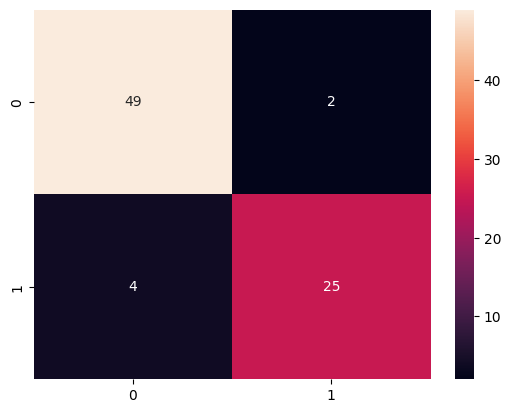

In [50]:
import seaborn as sns
sns.heatmap(cm,annot=True)

In [51]:
# from matplotlib.colors import ListedColormap
# X_set,y_set = X_train,y_train
# X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
#                     np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
# plt.contourf(X1,X2,clsf.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
#              alpha=0.75,cmap=ListedColormap(('red','blue')))
# plt.xlim(X1.min(),X1.max())
# plt.ylim(X2.min(),X2.max())
# for i,j in enumerate(np.unique(y_set)):
#     plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
# plt.legend()


In [52]:

# X_set,y_set = X_test,y_test
# X1,X2 = np.meshgrid(np.arange(start=X_set[:,0].min()-10,stop=X_set[:,0].max()+10,step=0.25),
#                     np.arange(start=X_set[:,1].min()-10,stop=X_set[:,1].max()+10,step=0.25))
# plt.contourf(X1,X2,clsf.predict(sc.transform(np.array([X1.ravel(),X2.ravel()]).T)).reshape(X1.shape),
#              alpha=0.75,cmap=ListedColormap(('red','blue')))
# plt.xlim(X1.min(),X1.max())
# plt.ylim(X2.min(),X2.max())
# for i,j in enumerate(np.unique(y_set)):
#     plt.scatter(X_set[y_set==j,0],X_set[y_set==j,1],c = ListedColormap(("black","white"))(i),label=j)
# plt.legend()
